In [1]:
import sys
print(sys.executable)

c:\Users\ASUS\Desktop\heart_disease_analysis\.venv\Scripts\python.exe


In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
#this to read the dataset
df=pd.read_csv("heart_disease_dataset.csv")
#this to show the first 5 rows of the dataset
df.head()
print("dataset shape:", df.shape)
#this to show the information of the dataset
df.info()
print("missing values per column:")
#this to show the missing values per column
print(df.isnull().sum())
#for the values of ca and thal the null values are over than 50% to 70% so we need to drop them bcz they will introduce bias in the model
df_clean=df.drop(columns=["ca","thal"]).copy()
print("cleaned dataset shape:", df_clean.shape)
print("missing values in cleaned dataset:")
print(df.isnull().sum())

dataset shape: (920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0


cleaned dataset shape: (920, 14)
missing values in cleaned dataset:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
target        0
dtype: int64
target value counts:
target
1    509
0    411
Name: count, dtype: int64


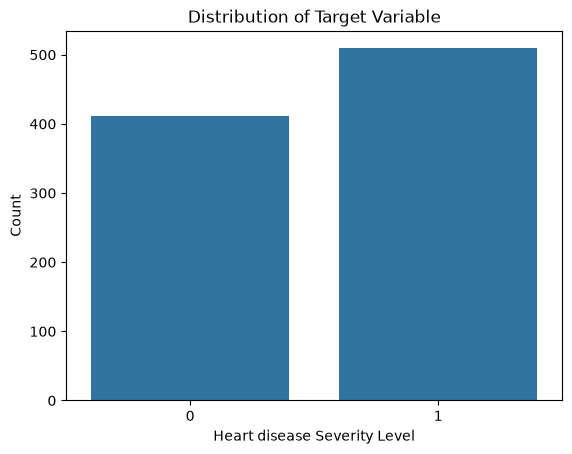

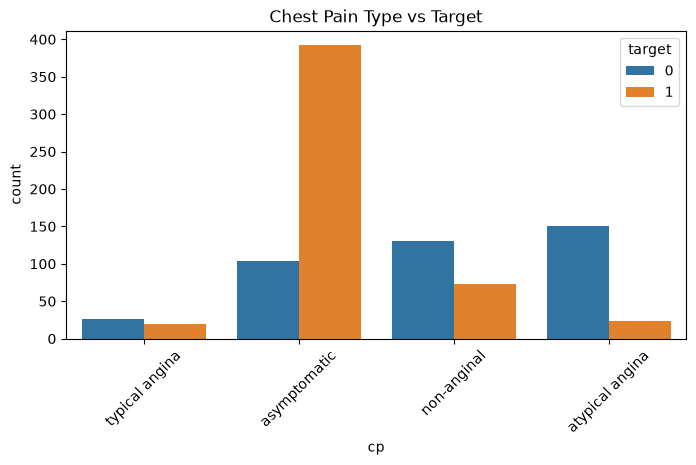

In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
#this to read the dataset
df=pd.read_csv("heart_disease_dataset.csv")
df_clean=df.drop(columns=["ca","thal"]).copy()
#ok now for the target values are 0,1,2... the number of heart attacks so we need to convert them to binary values 0 and 1 so we will consider the values of 0 as no heart attack and the values of 1,2,3,4 as heart attack so we will convert them to 1
df_clean['target'] = df_clean["num"].apply(lambda x: 1 if x > 0 else 0)
df_clean=df_clean.drop(columns=['num'])
print("cleaned dataset shape:", df_clean.shape)
print("missing values in cleaned dataset:")
print(df_clean.isnull().sum())


#i will drop the id bcz had no predictive power
df_clean=df_clean.drop(columns=['id'])
#as the threstbsp and chol can't be 0 so i will change them with NaN
df_clean['trestbps'] = df_clean['trestbps'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)
#now this nan values will be filled with the median of the column
df_clean=df_clean.fillna(df_clean.median(numeric_only=True))
df_clean.describe()
print("target value counts:")
print(df_clean['target'].value_counts())
#visualize the distribution of the target variable
sns.countplot(x='target', data=df_clean)
plt.title('Distribution of Target Variable')
plt.xlabel('Heart disease Severity Level')
plt.ylabel('Count')
plt.show()
#Compare Chest Pain Type (cp) against Target 
plt.figure(figsize=(8, 4))
sns.countplot(x='cp', hue='target', data=df_clean)
plt.title('Chest Pain Type vs Target')
plt.xticks(rotation=45)
plt.show()
df_clean.to_csv("cleaned_heart_disease_dataset.csv", index=False)

In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv("cleaned_heart_disease_dataset.csv")
df.head()


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0
